## Filtering and averaging data

First thing we need to do is to import the `MassJ` package.

In [1]:
using MassJ

We will use the same data set as in Example 1

In [2]:
using HTTP

data = download("https://raw.githubusercontent.com/ajgiuliani/MassJ.jl/master/test/test.mzXML", 
                expanduser("~/Downloads/test.mzXML")) ;

Now, using the `info` function of the `MassJ`package, we will see what is inside the file

In [3]:
info(data)

4-element Vector{String}:
 "6 scans"
 "MS1+"
 "MS2+ 1255.5  CID(CE=18)"
 "MS3+ 902.33  PQD(CE=35)"

In [4]:
s = load(data) ;

Getting chromatograms is straightforward using the `chromatogram` method.
We load the entiere chromatogram like this:

In [5]:
full_TIC = chromatogram(s)

IonCurrent(rt, 6 pts x=[0.138, 5.769] min, max ic=5.08195e6)

We may also filter the data to first MS level:

In [6]:
MS1_TIC = chromatogram(s, MassJ.Level(1))

IonCurrent(rt, 2 pts x=[0.138, 3.758] min, max ic=5.08195e6)

Or we may get only the mass spectrometry data which have been aquirred under CID conditions:

In [7]:
CID_TIC = chromatogram(s, MassJ.Activation_Method("CID"))

IonCurrent(rt, 2 pts x=[0.731, 4.344] min, max ic=12203.5)

We can also extract the chromatogram for a specific precursor ion:

In [8]:
mz902_TIC = chromatogram(s, MassJ.Precursor(902.33))

IonCurrent(rt, 2 pts x=[2.138, 5.769] min, max ic=11.3032)

Let plot the chromatograms, using theGR backend:

In [9]:
using Plots
gr()

Plots.GRBackend()

A recipe has also been defined for chromatogram data.

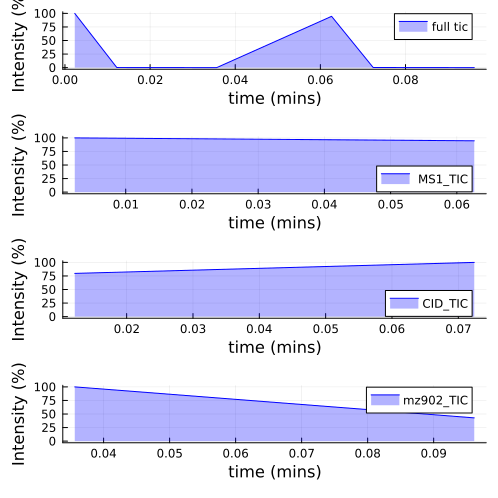

In [10]:
gr()
p1 = plot(full_TIC, label = "full tic")
p2 = plot(MS1_TIC, label = " MS1_TIC")
p3 = plot(CID_TIC, label = "CID_TIC")
p4 = plot(mz902_TIC, label = "mz902_TIC")

p = plot(p1, p2, p3, p4, layout = (4,1), size = (500,500))

Plots made using GR() may be saved to a file:

In [11]:
savefig(p, expanduser("~/Downloads/temp.png"))

"/home/alex/Downloads/temp.png"

Average mass spectra may be obtained using the proper `msfilter` functions:

In [12]:
ms1 = MassJ.average(s, MassJ.Level(1))                              # MS1 scans
ms2_CID = MassJ.average(s, MassJ.Activation_Method("CID"))          # CID scans
ms2_PQD = MassJ.average(s, MassJ.Activation_Method("PQD"))          # PQD scans
ms2_1255 = MassJ.average(s, MassJ.Precursor(1255.5));               # Precursor m/z = 1255.5 scans

Mass spectra may be plotted the same way as chromatograms:

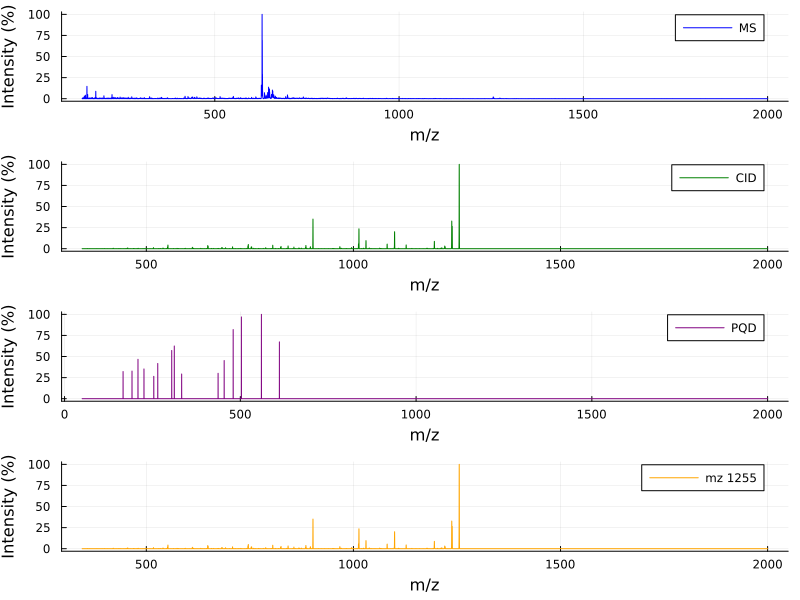

In [13]:
p5 = plot(ms1, label = "MS", color = :blue)
p6 = plot(ms2_CID, label = "CID", color = :green)
p7 = plot(ms2_PQD, label = "PQD", color = :purple)
p8 = plot(ms2_1255, label = "mz 1255", color = :orange)
plot(p5, p6, p7, p8, layout = (4,1), size = (800,600))